# Level 2 - Task 1
# Predicting House Prices with Linear Regression

## Objective

Build and evaluate a Linear Regression model to predict house prices
using features such as area, location, number of rooms, house age,
quality, and garage information.

### Import Libraries & Load the Dataset

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from sklearn.linear_model import LinearRegression, Ridge, Lasso

from sklearn.metrics import mean_squared_error, r2_score

In [3]:
df = pd.read_csv("train.csv")

df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [4]:
df.shape

(1460, 81)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

In [6]:
df.describe()

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.000000,1460.000000,1201.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1452.000000,1460.000000,...,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,730.500000,56.897260,70.049958,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.685262,443.639726,...,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890
std,421.610009,42.300571,24.284752,9981.264932,1.382997,1.112799,30.202904,20.645407,181.066207,456.098091,...,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883
min,1.000000,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,365.750000,20.000000,59.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,730.500000,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,...,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,1095.250000,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,166.000000,712.250000,...,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,1460.000000,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,...,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000


In [7]:
df.columns

Index(['Id', 'MSSubClass', 'MSZoning', 'LotFrontage', 'LotArea', 'Street',
       'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig',
       'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType',
       'HouseStyle', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd',
       'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType',
       'MasVnrArea', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual',
       'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinSF1',
       'BsmtFinType2', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'Heating',
       'HeatingQC', 'CentralAir', 'Electrical', '1stFlrSF', '2ndFlrSF',
       'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath',
       'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'KitchenQual',
       'TotRmsAbvGrd', 'Functional', 'Fireplaces', 'FireplaceQu', 'GarageType',
       'GarageYrBlt', 'GarageFinish', 'GarageCars', 'GarageArea', 'GarageQual',
       'GarageCond', 'PavedDrive

### Check Duplicate Rows

In [8]:
df.duplicated().sum()

np.int64(0)

### Check Missing Values

In [9]:
missing_values = df.isnull().sum()

missing_values = missing_values[missing_values > 0].sort_values(ascending=False)

missing_values

PoolQC          1453
MiscFeature     1406
Alley           1369
Fence           1179
MasVnrType       872
FireplaceQu      690
LotFrontage      259
GarageType        81
GarageYrBlt       81
GarageFinish      81
GarageQual        81
GarageCond        81
BsmtExposure      38
BsmtFinType2      38
BsmtQual          37
BsmtCond          37
BsmtFinType1      37
MasVnrArea         8
Electrical         1
dtype: int64

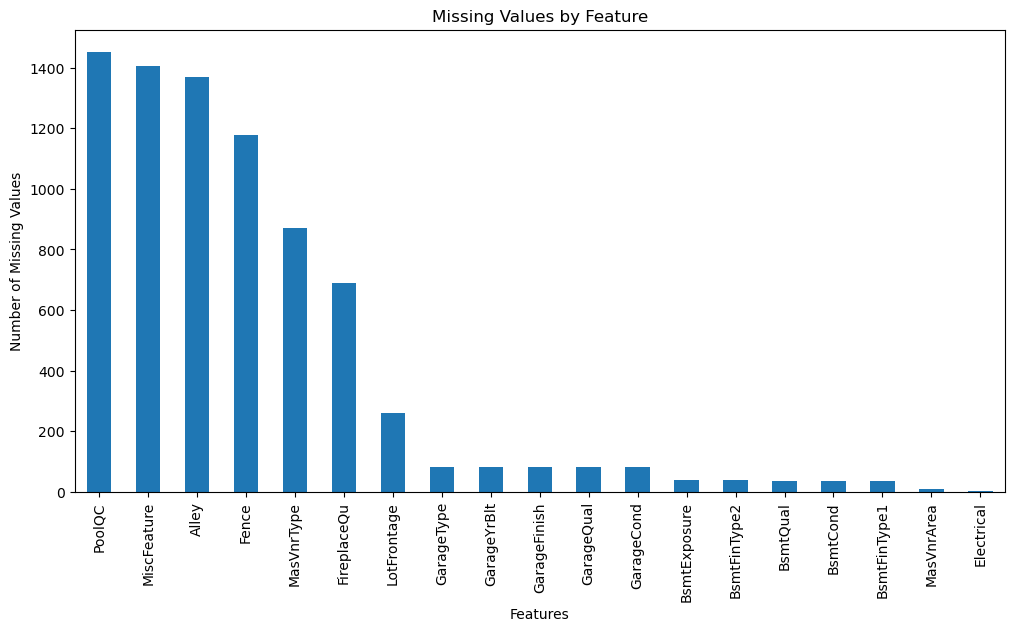

In [10]:
plt.figure(figsize=(12, 6))

missing_values.plot(kind="bar")

plt.title("Missing Values by Feature")
plt.xlabel("Features")
plt.ylabel("Number of Missing Values")

plt.xticks(rotation=90)
plt.show()

### Analyze Target Variable

In [12]:
df["SalePrice"].describe()

count      1460.000000
mean     180921.195890
std       79442.502883
min       34900.000000
25%      129975.000000
50%      163000.000000
75%      214000.000000
max      755000.000000
Name: SalePrice, dtype: float64

### Target Distribution

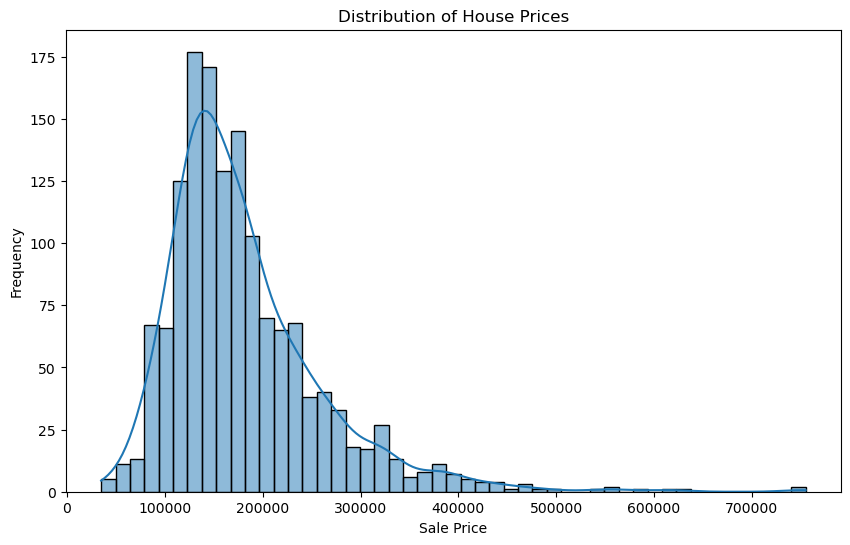

In [13]:
plt.figure(figsize=(10, 6))

sns.histplot(df["SalePrice"], kde=True)

plt.title("Distribution of House Prices")
plt.xlabel("Sale Price")
plt.ylabel("Frequency")

plt.show()

### Observation

The SalePrice distribution is right-skewed, indicating that most houses
are concentrated in the lower-to-middle price range while a smaller
number of properties have substantially higher prices.

### Feature Selection

Instead of immediately using all 79 features, start with a meaningful set of features.

We will use:

OverallQual

GrLivArea

Neighborhood

YearBuilt

TotRmsAbvGrd

FullBath

GarageCars

LotArea

### Create House Age

In [14]:
df["HouseAge"] = df["YrSold"] - df["YearBuilt"]

In [15]:
df[["YearBuilt", "YrSold", "HouseAge"]].head()

,YearBuilt,YrSold,HouseAge
0,2003,2008,5
1,1976,2007,31
2,2001,2008,7
3,1915,2006,91
4,2000,2008,8


### Select Features

In [16]:
features = [
    "GrLivArea",
    "OverallQual",
    "Neighborhood",
    "HouseAge",
    "TotRmsAbvGrd",
    "FullBath",
    "GarageCars",
    "LotArea"
]

X = df[features]
y = df["SalePrice"]

In [17]:
X.head()

,GrLivArea,OverallQual,Neighborhood,HouseAge,TotRmsAbvGrd,FullBath,GarageCars,LotArea
0,1710,7,CollgCr,5,8,2,2,8450
1,1262,6,Veenker,31,6,2,2,9600
2,1786,7,CollgCr,7,6,2,2,11250
3,1717,7,Crawfor,91,7,1,3,9550
4,2198,8,NoRidge,8,9,2,3,14260


In [18]:
y.head()

0    208500
1    181500
2    223500
3    140000
4    250000
Name: SalePrice, dtype: int64

### Numerical and Categorical Features

In [19]:
numeric_features = [
    "GrLivArea",
    "OverallQual",
    "HouseAge",
    "TotRmsAbvGrd",
    "FullBath",
    "GarageCars",
    "LotArea"
]

categorical_features = [
    "Neighborhood"
]

### Correlation Heatmap
Identify features most correlated with house price.

In [20]:
correlation_features = [
    "SalePrice",
    "GrLivArea",
    "OverallQual",
    "HouseAge",
    "TotRmsAbvGrd",
    "FullBath",
    "GarageCars",
    "LotArea"
]

correlation_matrix = df[correlation_features].corr()

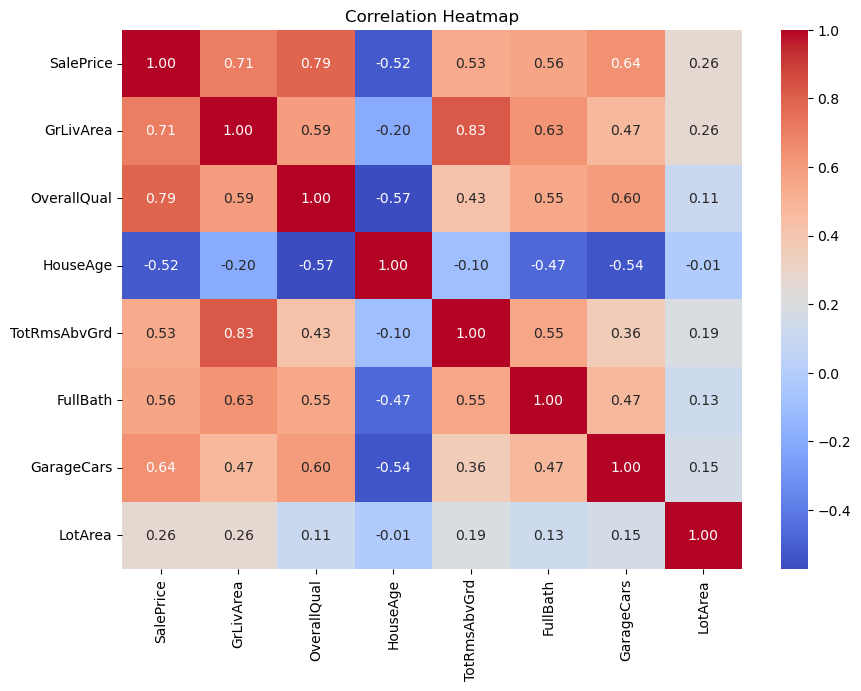

In [21]:
plt.figure(figsize=(10, 7))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")
plt.show()

### Feature Relationships

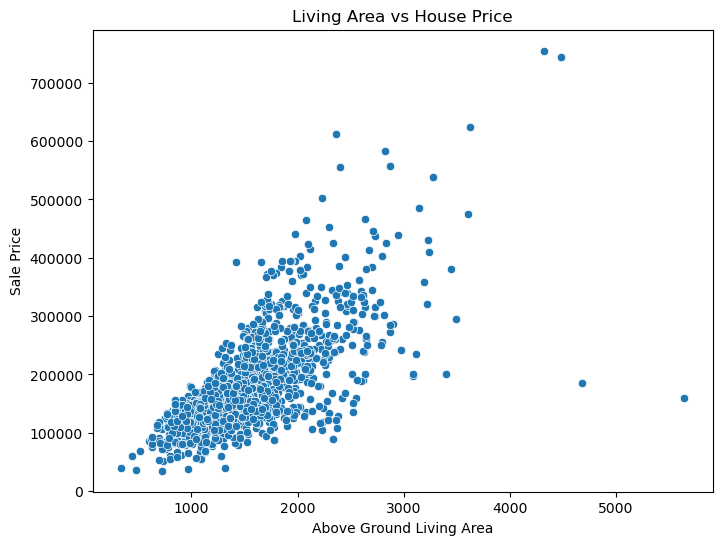

In [22]:
#Living Area vs Price
plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=df,
    x="GrLivArea",
    y="SalePrice"
)

plt.title("Living Area vs House Price")
plt.xlabel("Above Ground Living Area")
plt.ylabel("Sale Price")

plt.show()

### Quality vs Price

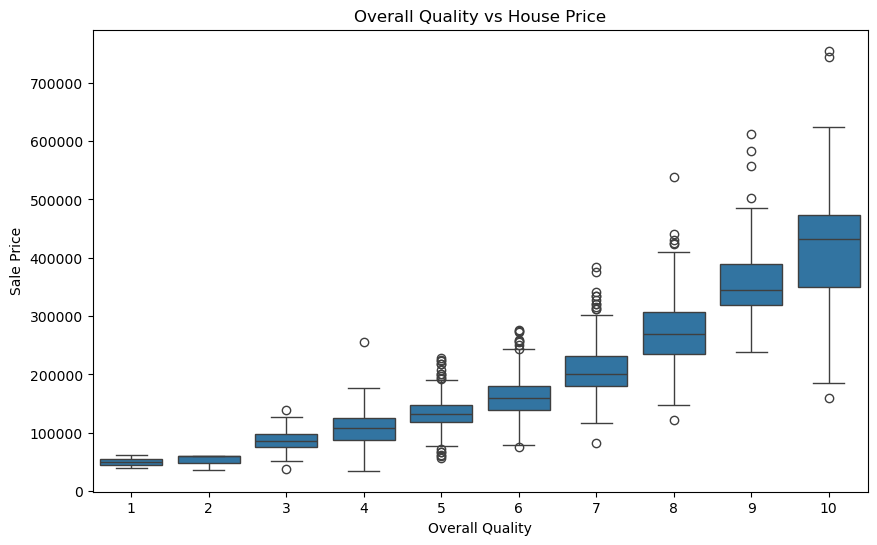

In [23]:
 plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df,
    x="OverallQual",
    y="SalePrice"
)

plt.title("Overall Quality vs House Price")
plt.xlabel("Overall Quality")
plt.ylabel("Sale Price")

plt.show()

### Location vs Price

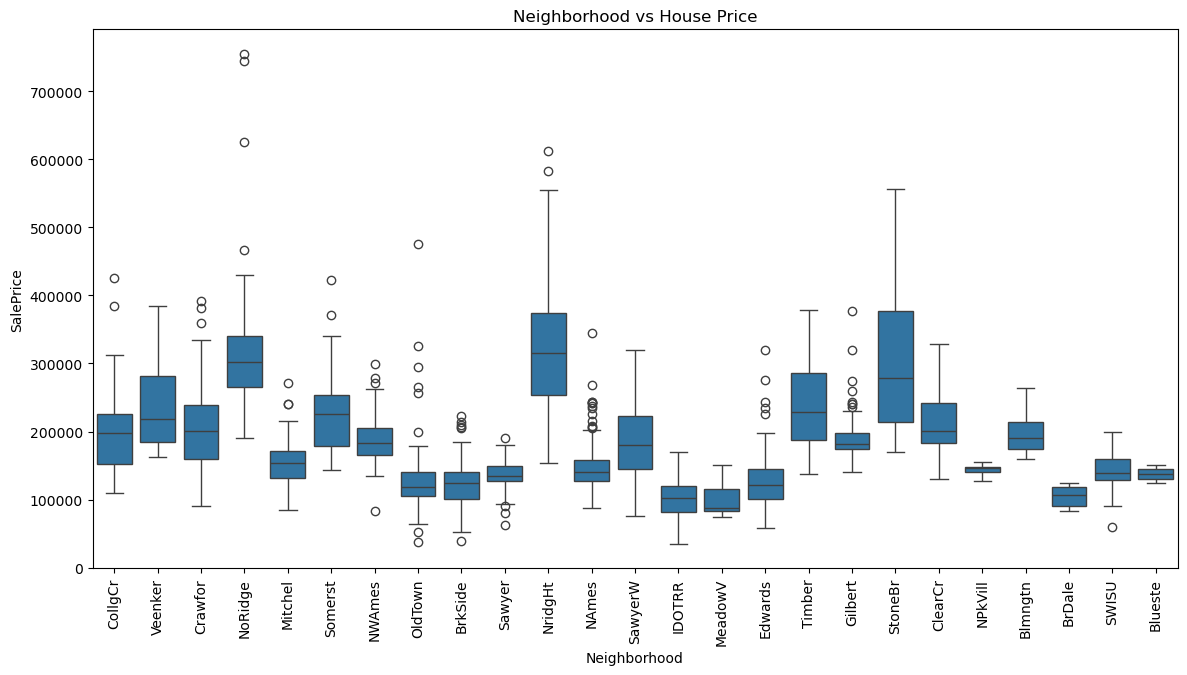

In [24]:
plt.figure(figsize=(14, 7))

sns.boxplot(
    data=df,
    x="Neighborhood",
    y="SalePrice"
)

plt.title("Neighborhood vs House Price")

plt.xticks(rotation=90)

plt.show()

### Train/Test Split

In [25]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

In [26]:
print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (1168, 8)
Testing data: (292, 8)


### Handle Missing Values and One-Hot Encoding

In [27]:
numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ]
)

In [28]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

### Linear Regression Model

In [29]:
linear_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", LinearRegression())
    ]
)

In [30]:
#Train
linear_model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['GrLivArea', 'OverallQual',
                                                   'HouseAge', 'TotRmsAbvGrd',
                                                   'FullBath', 'GarageCars',
                                                   'LotArea']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['Neighborhood'])])),
                ('model', LinearRegression())])

### Make Predictions

In [31]:
y_pred = linear_model.predict(X_test)

In [32]:
comparison = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred
})

comparison.head(10)

,Actual,Predicted
0,154500,142371.372019
1,325000,324236.740254
2,115000,108868.769535
3,159000,177863.124839
4,315500,269880.461378
5,75500,54042.440637
6,311500,238508.597857
7,146000,154472.801318
8,84500,54773.377355
9,135500,132617.756658


### Evaluate the Model

In [33]:
mse = mean_squared_error(y_test, y_pred)

print("Mean Squared Error:", mse)

Mean Squared Error: 1405700532.2485783


In [34]:
rmse = np.sqrt(mse)

print("Root Mean Squared Error:", rmse)

Root Mean Squared Error: 37492.67304752461


In [35]:
r2 = r2_score(y_test, y_pred)

print("R² Score:", r2)

R² Score: 0.8167352346851388


### Final evaluation

In [36]:
print("Model Evaluation")
print("------------------------")
print(f"Mean Squared Error : {mse:,.2f}")
print(f"Root Mean Squared Error : {rmse:,.2f}")
print(f"R² Score : {r2:.4f}")

Model Evaluation
------------------------
Mean Squared Error : 1,405,700,532.25
Root Mean Squared Error : 37,492.67
R² Score : 0.8167


### Actual vs Predicted Price Plot

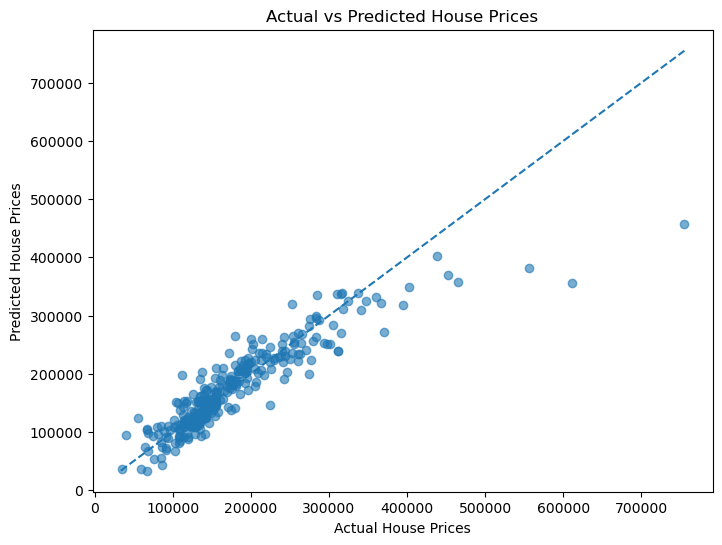

In [37]:
plt.figure(figsize=(8, 6))

plt.scatter(
    y_test,
    y_pred,
    alpha=0.6
)

plt.xlabel("Actual House Prices")
plt.ylabel("Predicted House Prices")
plt.title("Actual vs Predicted House Prices")

min_value = min(y_test.min(), y_pred.min())
max_value = max(y_test.max(), y_pred.max())

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle="--"
)

plt.show()

### Residual Analysis

In [38]:
residuals = y_test - y_pred

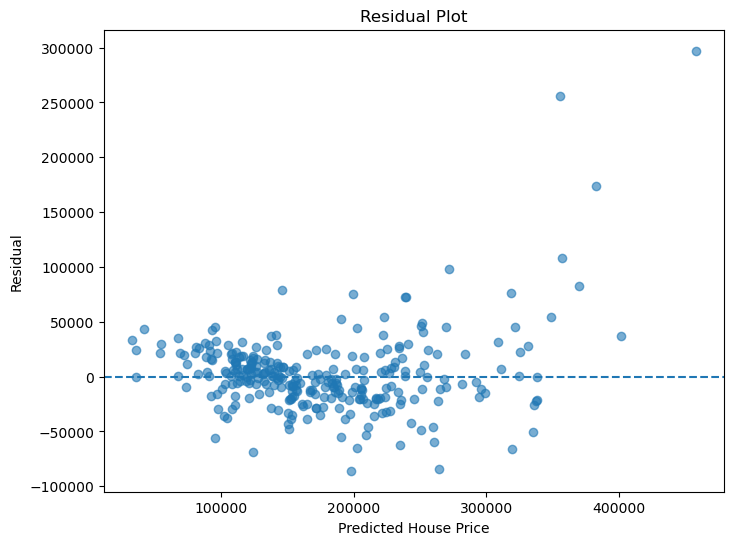

In [39]:
plt.figure(figsize=(8, 6))

plt.scatter(
    y_pred,
    residuals,
    alpha=0.6
)

plt.axhline(
    y=0,
    linestyle="--"
)

plt.xlabel("Predicted House Price")
plt.ylabel("Residual")
plt.title("Residual Plot")

plt.show()

### Interpret Residual Plot
#### Residual Analysis

The residual plot is used to check whether prediction errors are randomly
distributed around zero. A random distribution with no clear systematic
pattern suggests that the linear model is reasonably appropriate.

### Coefficient Analysis

In [40]:
feature_names = linear_model.named_steps[
    "preprocessor"
].get_feature_names_out()

In [41]:
coefficients = linear_model.named_steps[
    "model"
].coef_

In [42]:
coef_df = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": coefficients
})

In [43]:
coef_df = coef_df.sort_values(
    by="Coefficient",
    ascending=False
)

In [44]:
coef_df.head(10)

,Feature,Coefficient
29,cat__Neighborhood_StoneBr,53283.334636
23,cat__Neighborhood_NridgHt,48555.984836
22,cat__Neighborhood_NoRidge,44466.136975
31,cat__Neighborhood_Veenker,38325.945445
13,cat__Neighborhood_Crawfor,24844.896932
0,num__GrLivArea,24805.001851
1,num__OverallQual,24272.699752
11,cat__Neighborhood_ClearCr,13855.880003
5,num__GarageCars,9688.796439
6,num__LotArea,7587.099513


### Visualize Coefficients

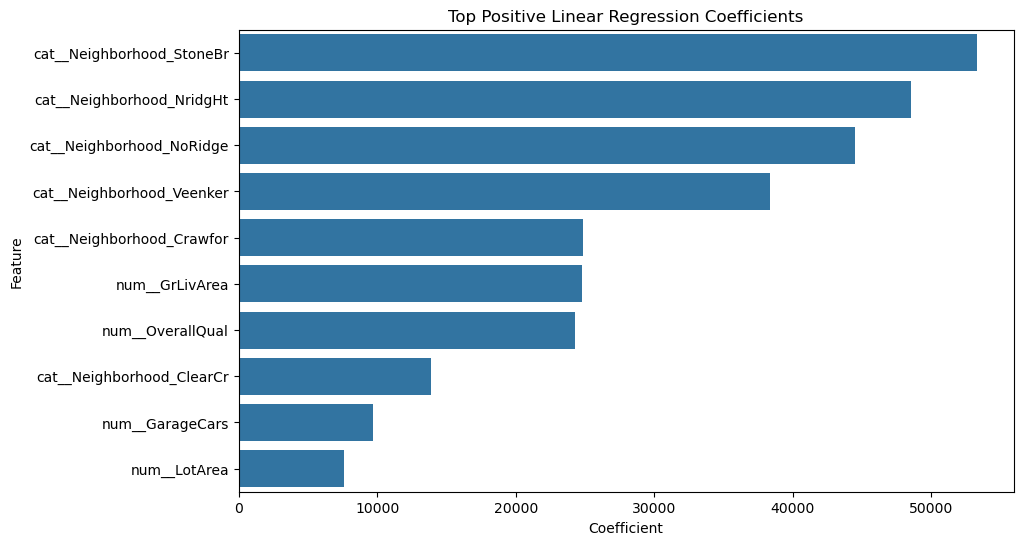

In [45]:
top_positive = coef_df.head(10)

plt.figure(figsize=(10, 6))

sns.barplot(
    data=top_positive,
    x="Coefficient",
    y="Feature"
)

plt.title("Top Positive Linear Regression Coefficients")

plt.show()

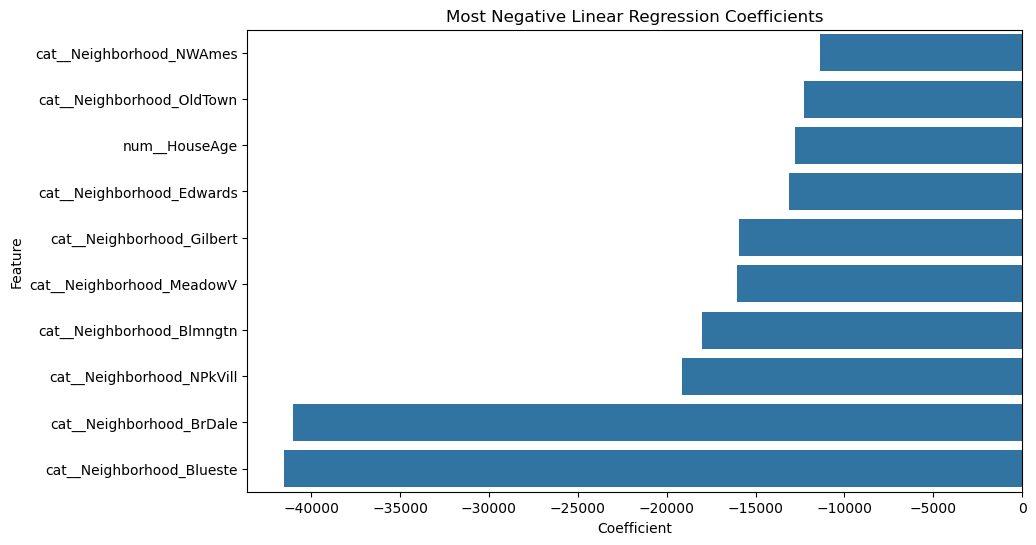

In [46]:
#Negative
top_negative = coef_df.tail(10)

plt.figure(figsize=(10, 6))

sns.barplot(
    data=top_negative,
    x="Coefficient",
    y="Feature"
)

plt.title("Most Negative Linear Regression Coefficients")

plt.show()

### BONUS: Ridge Regression

In [47]:
from sklearn.linear_model import Ridge, Lasso

### Ridge

In [48]:
ridge_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", Ridge(alpha=10.0))
    ]
)

ridge_model.fit(X_train, y_train)

ridge_pred = ridge_model.predict(X_test)

ridge_mse = mean_squared_error(y_test, ridge_pred)
ridge_rmse = np.sqrt(ridge_mse)
ridge_r2 = r2_score(y_test, ridge_pred)

print("Ridge Regression")
print("-------------------------")
print(f"MSE  : {ridge_mse:,.2f}")
print(f"RMSE : {ridge_rmse:,.2f}")
print(f"R²   : {ridge_r2:.4f}")

Ridge Regression
-------------------------
MSE  : 1,445,432,229.67
RMSE : 38,018.84
R²   : 0.8116


### Lasso Regression

In [49]:
lasso_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", Lasso(alpha=100.0, max_iter=10000))
    ]
)

lasso_model.fit(X_train, y_train)

lasso_pred = lasso_model.predict(X_test)

lasso_mse = mean_squared_error(y_test, lasso_pred)
lasso_rmse = np.sqrt(lasso_mse)
lasso_r2 = r2_score(y_test, lasso_pred)

print("Lasso Regression")
print("-------------------------")
print(f"MSE  : {lasso_mse:,.2f}")
print(f"RMSE : {lasso_rmse:,.2f}")
print(f"R²   : {lasso_r2:.4f}")

Lasso Regression
-------------------------
MSE  : 1,413,330,031.68
RMSE : 37,594.28
R²   : 0.8157


### Compare All Models

In [50]:
model_comparison = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Ridge Regression",
        "Lasso Regression"
    ],
    "MSE": [
        mse,
        ridge_mse,
        lasso_mse
    ],
    "RMSE": [
        rmse,
        ridge_rmse,
        lasso_rmse
    ],
    "R2": [
        r2,
        ridge_r2,
        lasso_r2
    ]
})

model_comparison

,Model,MSE,RMSE,R2
0,Linear Regression,1.405701e+09,37492.673048,0.816735
1,Ridge Regression,1.445432e+09,38018.840457,0.811555
2,Lasso Regression,1.413330e+09,37594.281901,0.815741


### Visualize Model Comparison

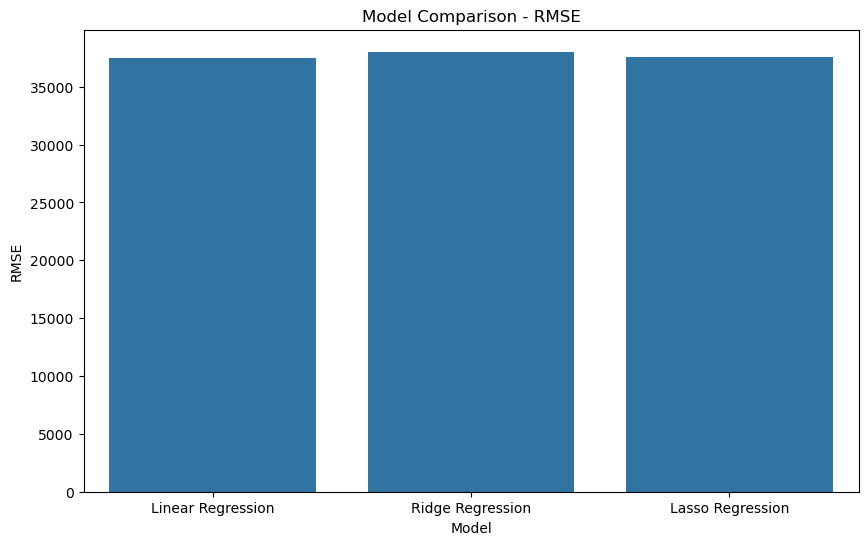

In [51]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=model_comparison,
    x="Model",
    y="RMSE"
)

plt.title("Model Comparison - RMSE")

plt.show()

### Final Model Selection

In [52]:
best_model = model_comparison.loc[
    model_comparison["RMSE"].idxmin()
]

best_model

Model    Linear Regression
MSE      1405700532.248578
RMSE          37492.673048
R2                0.816735
Name: 0, dtype: object

In [53]:
print(
    f"The best performing model based on RMSE is "
    f"{best_model['Model']}."
)

The best performing model based on RMSE is Linear Regression.


### Final Conclusion

In this project, a Linear Regression model was developed to predict
house prices using features such as living area, overall quality,
neighborhood, house age, number of rooms, bathrooms, garage capacity,
and lot area.

The dataset was explored using descriptive statistics, missing-value
analysis, distribution plots, correlation analysis, and feature
relationship visualizations.

Categorical variables were converted into numerical form using One-Hot
Encoding, while missing numerical values were handled using median
imputation. The dataset was divided into 80% training data and 20%
testing data.

The Linear Regression model was evaluated using Mean Squared Error (MSE),
Root Mean Squared Error (RMSE), and R² Score. Actual versus predicted
plots and residual analysis were also performed to evaluate model
performance.

Finally, Linear Regression was compared with Ridge and Lasso
regularization to determine whether regularization improved predictive
performance.

The project demonstrates an end-to-end machine learning workflow,
including data exploration, preprocessing, feature engineering,
regression modeling, evaluation, visualization, and interpretation.